In [1]:
import pandas as pd
import numpy as np
import matplotlib

In [2]:
df = pd.read_csv('AmesHousing.csv')

In [3]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1920,1921,535154080,20,RL,75.0,9750,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,Shed,500,4,2007,COD,Normal,157900
1014,1015,527252080,120,RL,60.0,8118,Pave,NaN,Reg,HLS,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,334000
2157,2158,907295040,20,RL,73.0,17227,Pave,NaN,IR2,Lvl,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,246900
1208,1209,534400060,20,RL,100.0,10175,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,180500
569,570,533213020,120,FV,NaN,4217,Pave,Pave,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,195000


In [4]:
df.shape

(2930, 82)

In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [6]:
missing_data = (df.isnull().sum() / len(df)) * 100
missing_data = missing_data[missing_data>0].sort_values(ascending=False)
print(missing_data)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64


In [7]:
df = df.drop(columns = ['Pool QC','Misc Feature','Alley'])
# df = df.drop(['Pool QC' , 'Misc Feature' , 'Alley'], axis = 1)

In [8]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,3Ssn Porch,Screen Porch,Pool Area,Fence,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2128,2129,907187040,60,RL,47.0,10820,Pave,IR2,Lvl,AllPub,...,0,0,0,NaN,0,3,2007,WD,Normal,235500
431,432,528110010,60,RL,97.0,13478,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,6,2009,ConLI,Normal,451950
1712,1713,528172050,20,RL,70.0,9926,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,5,2007,WD,Normal,245700
2601,2602,535380010,70,RL,60.0,7200,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,4,2006,WD,Normal,155500
543,544,531379050,60,RL,43.0,11492,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,4,2009,WD,Normal,220000


In [9]:
import seaborn as sns

<Axes: xlabel='SalePrice', ylabel='Count'>

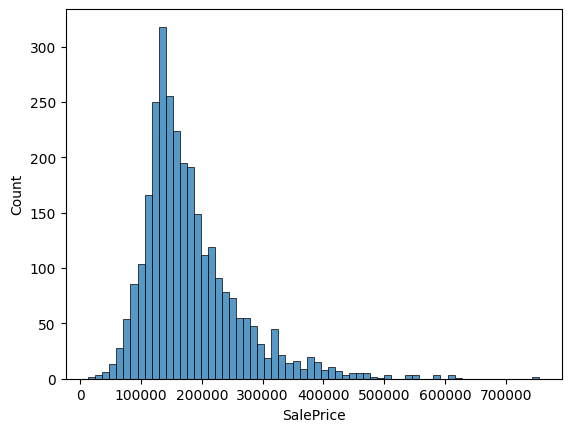

In [10]:
sns.histplot(df['SalePrice'])

In [11]:
# x = df['Gr Liv Area']
# y = df['SalePrice']
# sns.scatterplot(x,y)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

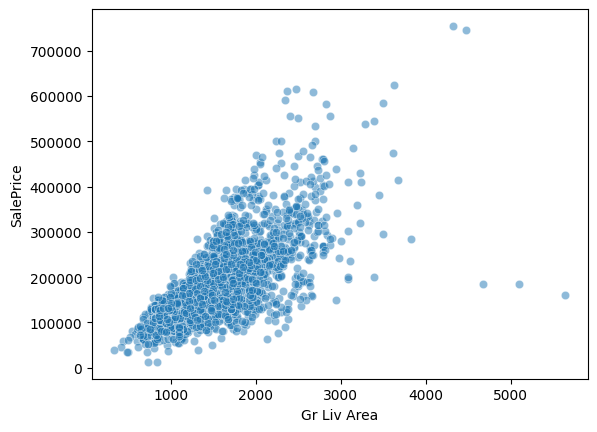

In [12]:
sns.scatterplot(data = df , x = 'Gr Liv Area' , y = 'SalePrice',alpha=0.5)

In [13]:
outliers_indexes = df[(df['Gr Liv Area']>4000) & (df['SalePrice']<300000)].index

In [14]:
df = df.drop(outliers_indexes)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

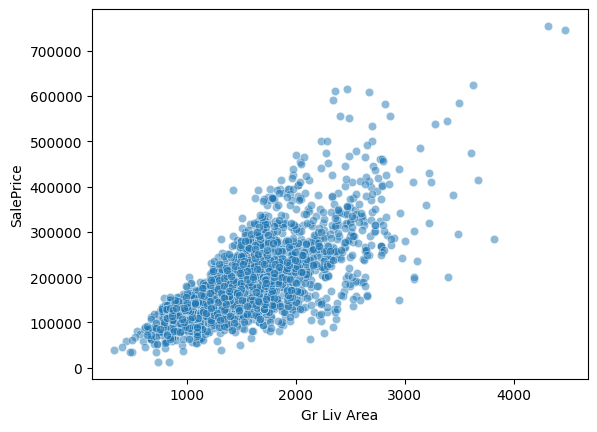

In [15]:
sns.scatterplot(data = df , x = 'Gr Liv Area' , y = 'SalePrice' , alpha = 0.5)

In [16]:
df.sample(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,3Ssn Porch,Screen Porch,Pool Area,Fence,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
421,422,528102140,60,RL,110.0,14257,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,6,2009,WD,Normal,462000
1184,1185,534104100,60,FV,NaN,7500,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,4,2008,WD,Normal,205000
1663,1664,527402150,20,RL,NaN,10530,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,3,2007,WD,Normal,143250
379,380,527355150,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,...,0,0,0,MnPrv,0,7,2009,WD,Normal,278000
773,774,905107310,85,RL,NaN,8014,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,6,2009,WD,Normal,149900
143,144,535153070,20,RL,73.0,8760,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,4,2010,WD,Normal,148000
1216,1217,534427040,20,RL,80.0,10721,Pave,IR1,Lvl,AllPub,...,0,0,0,NaN,0,10,2008,WD,Normal,142000
2421,2422,528228340,120,RL,NaN,3196,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,5,2006,WD,Normal,215000
432,433,528110020,20,RL,105.0,13693,Pave,Reg,Lvl,AllPub,...,0,0,0,NaN,0,3,2009,WD,Normal,610000
2312,2313,527107020,60,RL,NaN,13041,Pave,IR2,Lvl,AllPub,...,0,0,0,NaN,0,2,2006,WD,Normal,170000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2927 entries, 0 to 2929
Data columns (total 79 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2927 non-null   int64  
 1   PID              2927 non-null   int64  
 2   MS SubClass      2927 non-null   int64  
 3   MS Zoning        2927 non-null   object 
 4   Lot Frontage     2437 non-null   float64
 5   Lot Area         2927 non-null   int64  
 6   Street           2927 non-null   object 
 7   Lot Shape        2927 non-null   object 
 8   Land Contour     2927 non-null   object 
 9   Utilities        2927 non-null   object 
 10  Lot Config       2927 non-null   object 
 11  Land Slope       2927 non-null   object 
 12  Neighborhood     2927 non-null   object 
 13  Condition 1      2927 non-null   object 
 14  Condition 2      2927 non-null   object 
 15  Bldg Type        2927 non-null   object 
 16  House Style      2927 non-null   object 
 17  Overall Qual     29

In [35]:
numerica_col = ["Year Built","Garage Cars","1st Flr SF","Gr Liv Area","Full Bath","Year Built","Bedroom AbvGr"]
ord_features = ['Exter Qual', 'Kitchen Qual', 'Bsmt Qual', 'Heating QC']
nom_features = ['Neighborhood', 'Foundation', 'House Style', 'Bldg Type']

In [36]:
quality_ranks = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_categories = [quality_ranks, quality_ranks, quality_ranks, quality_ranks]

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [38]:

num_pipeline = Pipeline(
    steps = [
        ('impute' , SimpleImputer(strategy='median')),
        ('scale' , StandardScaler())
    ])


cat_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [39]:
preprocessor = ColumnTransformer(
    transformers = [
        ('number_stuff' , num_pipeline , numerica_col),
        ('name_stuff' , cat_pipeline, nom_features)
    ]
)

In [40]:
x = df.drop(columns='SalePrice')
y = df['SalePrice']

In [41]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline(steps=[
    ('cleaner' , preprocessor),
    ('model' , LinearRegression())
])

In [43]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('cleaner',
                 ColumnTransformer(transformers=[('number_stuff',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Year Built', 'Garage Cars',
                                                   '1st Flr SF', 'Gr Liv Area',
                                                   'Full Bath', 'Year Built',
                                                   'Bedroom AbvGr']),
                                                 ('name_stuff',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Neighborhood', 'Foundation',
                                                   'House Style',
                                                   'Bldg Type'])])),
                ('model', LinearRegression())])

In [44]:
# debugger part
# print(df.columns.tolist())
# # This removes leading/trailing spaces from every column name in your data
# df.columns = df.columns.str.strip()

# Make sure these match the CLEAN names
# num_features = ['Gr Liv Area', 'Lot Area', 'Year Built', '1st Flr SF', 'Full Bath']
# # ... and so on for your other lists

In [45]:
score = model_pipeline.score(X_test,y_test)
print(f"Model accuracy (R^2) :- {score:.4f}")

Model accuracy (R^2) :- 0.8544


In [49]:
predictions = model_pipeline.predict(X_test)
results = pd.DataFrame({
    'Actual Sale Price': y_test,
    'Predicted Sale Price': predictions
})
print(results.head())

      Actual Sale Price  Predicted Sale Price
2393             298236         335038.352878
196              132000         141159.937018
2310             183500         177882.439761
1732             198444         209413.961701
1100             250000         293548.367403


<Axes: xlabel='SalePrice'>

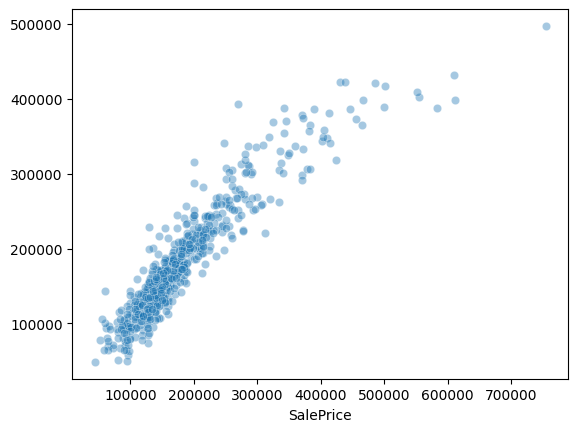

In [50]:
sns.scatterplot(x=y_test,y=predictions,alpha=0.4)

In [53]:
# # Gemini plot given
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 6))

# # Plotting the Actual vs Predicted
# sns.scatterplot(x=y_test, y=predictions, alpha=0.4)

# # Adding a 'Perfect Prediction' line (Diagonal)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# plt.xlabel('Actual Sale Price')
# plt.ylabel('Predicted Sale Price')
# plt.title('Actual vs. Predicted (R² = 0.85)')
# plt.show()

In [56]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
# print(f"The MSE is :- {mse:.4f}")
rmse = np.sqrt(mse)
print(f"The RMSE is :- {rmse:.4f}")

The RMSE is :- 34259.7901


In [59]:
avg = df['SalePrice'].mean()
percent = (rmse/avg)*100
print(f"The error percentage is :- {percent:.4f}")

The error percentage is :- 18.9489


In [61]:
import joblib
joblib.dump(model_pipeline, 'ames_housing_model.pkl')

['ames_housing_model.pkl']

In [62]:
# Extracting features


In [69]:
feature_name = model_pipeline.named_steps['cleaner'].get_feature_names_out()

In [70]:
weights = model_pipeline.named_steps['model'].coef_

In [72]:
import pandas as pd

# Combine names and weights
importance_df = pd.DataFrame({
    'Feature': feature_name,
    'Weight': weights
})

# Sort by the absolute value (importance can be positive or negative)
importance_df['Abs_Weight'] = importance_df['Weight'].abs()
importance_df = importance_df.sort_values(by='Abs_Weight', ascending=False)

/tmp/ipykernel_11838/836548513.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Weight', y='Feature', palette='viridis')


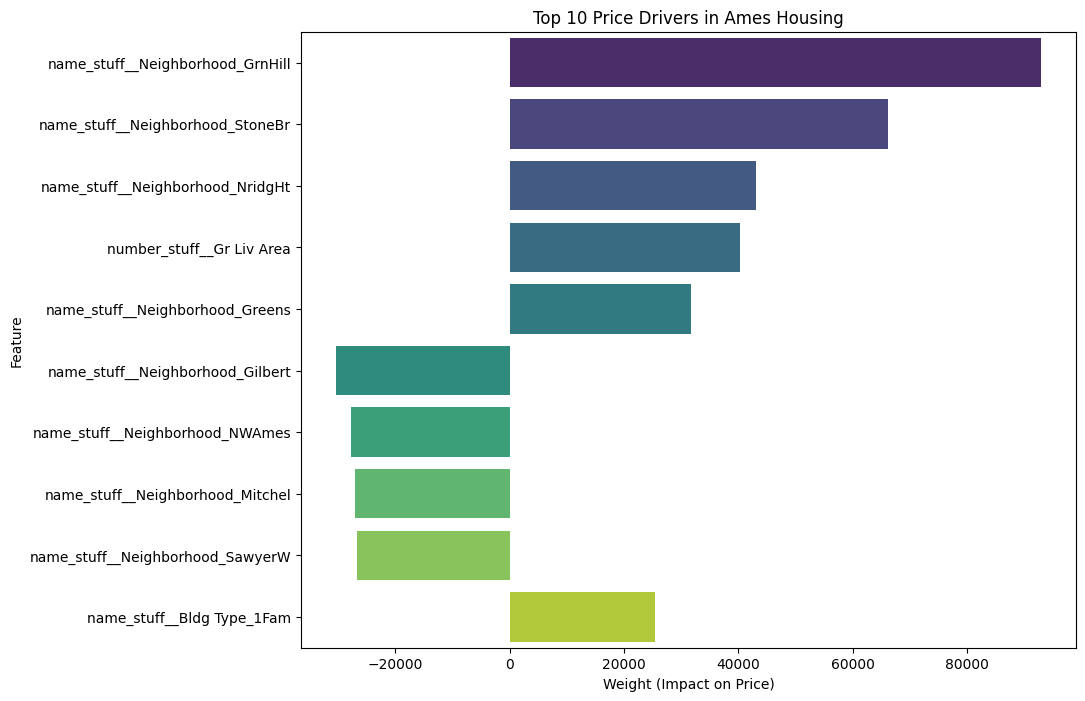

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(10), x='Weight', y='Feature', palette='viridis')
plt.title('Top 10 Price Drivers in Ames Housing')
plt.xlabel('Weight (Impact on Price)')
plt.show()